# Taller Semana 4 — Guía de Preparación de la Información
### Minería de Datos · Unidad 2

**Dataset:** `airq_dt.csv` (calidad del aire: Ozono, Radiación Solar, Viento, Temperatura, Mes, Día)

Este taller es una **guía práctica** que sigue una secuencia lógica de preparación de datos, en el mismo orden en que se vio en la Clase 4:

| Paso | Tema | Pregunta que responde |
|---|---|---|
| 1 | **Distribución Normal** | ¿Esta variable se comporta como una normal? Si no, ¿puedo transformarla? |
| 2 | **Valores atípicos (outliers)** | ¿Hay observaciones extremas? ¿Son errores o datos válidos? |
| 3 | **Datos faltantes** | ¿Cuántos datos faltan, con qué patrón, y cómo los trato? |

**Por qué este orden importa:** las decisiones no son independientes. Si una variable no es normal y tiene outliers, eso **cambia** qué método de imputación de datos faltantes conviene usar (por ejemplo, mediana en vez de media). Por eso cada sección retoma lo que se descubrió en la anterior — esa es la idea central de este taller.

A lo largo del notebook vas a ver bloques como este:

> 🔎 **HALLAZGO:** texto con la conclusión de cada paso, generado automáticamente a partir del resultado real del cálculo (no es un texto fijo — cambia si cambian los datos).

Tu tarea como estudiante es leer los comentarios de **por qué** se usa cada herramienta y las **consideraciones** antes de tomar una decisión, no solo ejecutar el código.


## 0. Preparación del entorno

Importamos las librerías que vamos a necesitar y definimos una función auxiliar `hallazgo()` para imprimir de forma resaltada las conclusiones de cada paso (así se distinguen fácilmente del resto del código y su salida).


In [1]:
# Librerías de manejo de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno          # visualización especializada en datos faltantes
import statsmodels.api as sm      # para el Q-Q plot

# Librerías de pruebas estadísticas y preprocesamiento
from scipy.stats import skew, variation, kstest, shapiro, norm
from sklearn.impute import SimpleImputer

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)


def hallazgo(texto):
    # Imprime un hallazgo/conclusion resaltado, para diferenciarlo
    # de las salidas normales de calculos o graficos.
    linea = "=" * 78
    print(linea)
    print("🔎 HALLAZGO:", texto)
    print(linea)


In [2]:
# Cargar los datos
airq_dt = pd.read_csv("airq_dt.csv")

# Dimensiones y vista previa: SIEMPRE se debe inspeccionar el dataset
# antes de decidir qué herramientas de preparación aplicar.
print("Dimensiones (filas, columnas):", airq_dt.shape)
print()
print(airq_dt.head())
print()
airq_dt.info()


Dimensiones (filas, columnas): (100, 6)

   Ozono  RadSol  Vient  Temp  Mes  Dia
0   21.0   259.0   15.5    76    9   12
1   32.0    92.0   12.0    61    5   24
2   20.0    37.0    9.2    65    6   18
3    NaN   139.0    8.6    82    7   11
4   28.0   273.0   11.5    82    8   13

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ozono   82 non-null     float64
 1   RadSol  96 non-null     float64
 2   Vient   100 non-null    float64
 3   Temp    100 non-null    int64  
 4   Mes     100 non-null    int64  
 5   Dia     100 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 4.8 KB


---
## 1. Distribución Normal: ¿los datos siguen una curva normal?

### ¿Por qué se hace este análisis?

Muchas técnicas estadísticas y de minería de datos (regresión lineal, pruebas t, control de calidad basado en la regla empírica 68-95-99.7, ciertos métodos de detección de outliers, PCA, etc.) **asumen** que la variable analizada se distribuye normalmente. Si esa asunción no se cumple, los resultados de esas técnicas pueden ser poco confiables. Por eso este es el **primer paso**: antes de aplicar otras herramientas, hay que saber con qué tipo de variable estamos trabajando.

### Consideraciones antes de decidir

- **No basta con un solo método.** Un histograma puede parecer "casi normal" a simple vista pero fallar un test formal, y viceversa. Por eso se combinan métodos **gráficos** (histograma + curva normal teórica, Q-Q plot) con métodos **formales** (tests de hipótesis).
- **El tamaño de la muestra importa.** Shapiro-Wilk es más apropiado para muestras pequeñas/medianas (n < 50); Kolmogórov-Smirnov es más robusto en muestras grandes. Con n≈100 como en este dataset, usamos ambos y los comparamos.
- **La conclusión es sobre una variable, no sobre todo el dataset.** Cada columna numérica debe evaluarse por separado.
- **Un p-value bajo no dice "qué tan distinta" es la distribución**, solo que hay evidencia estadística de que no es normal. Por eso conviene mirar también el coeficiente de asimetría (skewness): valores cercanos a 0 sugieren simetría; valores >1 o <-1 indican asimetría fuerte.


In [18]:
# Estadística descriptiva de Ozono: primer vistazo cuantitativo antes
# de cualquier test formal. La media, mediana, desviación estándar,
# asimetría (skew) y coeficiente de variación ya dan pistas de si la
# variable podría no ser simétrica.
print(airq_dt['Ozono'].describe())
print()

coef_asimetria = skew(airq_dt['Ozono'].dropna())
coef_variacion = variation(airq_dt['Ozono'].dropna())
print("Coeficiente de asimetría (skewness):", round(coef_asimetria, 3))
print("Coeficiente de variación:", round(coef_variacion, 3))

# Interpretación automática del coeficiente de asimetría
if abs(coef_asimetria) < 0.5:
    interpretacion_skew = "aproximadamente simétrica"
elif abs(coef_asimetria) < 1:
    interpretacion_skew = "con asimetría moderada"
else:
    interpretacion_skew = "con asimetría fuerte (cola larga hacia " + \
        ("la derecha" if coef_asimetria > 0 else "la izquierda") + ")"

hallazgo(f"La variable Ozono es {interpretacion_skew} "
          f"(skewness = {coef_asimetria:.2f}). Esto ya es una señal de alerta "
          f"sobre el supuesto de normalidad, pero falta confirmarlo con los "
          f"gráficos y tests formales que siguen.")


count     82.000000
mean      41.073171
std       35.022314
min        1.000000
25%       16.000000
50%       29.000000
75%       51.500000
max      168.000000
Name: Ozono, dtype: float64

Coeficiente de asimetría (skewness): 1.393
Coeficiente de variación: 0.847
🔎 HALLAZGO: La variable Ozono es con asimetría fuerte (cola larga hacia la derecha) (skewness = 1.39). Esto ya es una señal de alerta sobre el supuesto de normalidad, pero falta confirmarlo con los gráficos y tests formales que siguen.


### 1.1 Métodos gráficos

**Por qué:** los métodos gráficos permiten *ver* la forma de la distribución y detectar patrones (colas largas, bimodalidad, etc.) que un solo número (como el p-value) no muestra.


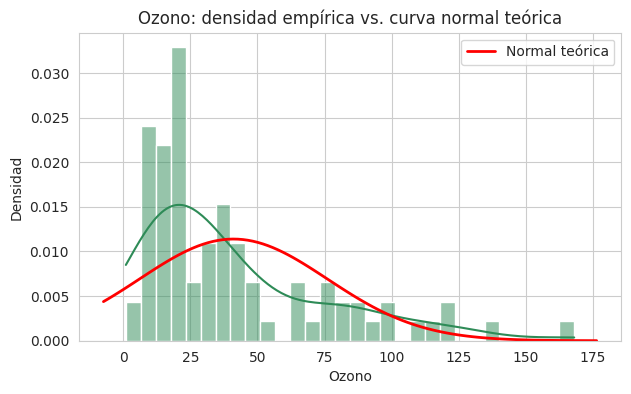

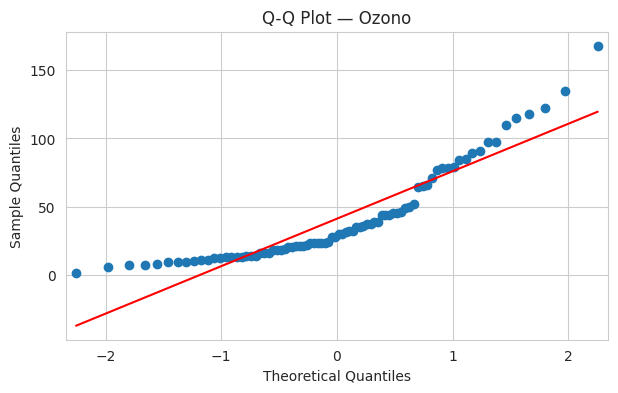

In [4]:
# Histograma + densidad empírica (KDE) + curva normal teórica superpuesta.
# La comparación visual entre la curva verde/azul (datos reales) y la curva
# roja (normal teórica con la misma media y desviación estándar) es la forma
# más intuitiva de detectar diferencias con la normalidad.

sns.histplot(airq_dt['Ozono'].dropna(), kde=True, stat="density",
             color="seagreen", bins=30)

mean_oz = airq_dt['Ozono'].mean()
std_oz = airq_dt['Ozono'].std()

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean_oz, std_oz)
plt.plot(x, p, 'r', linewidth=2, label="Normal teórica")

plt.xlabel("Ozono")
plt.ylabel("Densidad")
plt.title("Ozono: densidad empírica vs. curva normal teórica")
plt.legend()
plt.show()

# Q-Q plot: compara los cuantiles observados con los cuantiles esperados
# bajo una distribución normal. Si los datos fueran normales, los puntos
# caerían sobre la línea diagonal roja.
sm.qqplot(airq_dt['Ozono'].dropna(), line='s')
plt.title("Q-Q Plot — Ozono")
plt.show()


### 1.2 Métodos formales: tests de bondad de ajuste

**Por qué:** los tests formales entregan una conclusión objetiva (no depende de "cómo se ve" el gráfico) basada en un criterio estadístico. Usamos:

- **Kolmogórov-Smirnov (KS):** compara la distribución empírica acumulada de los datos con la de una normal teórica con la misma media y desviación estándar. Más robusto en muestras grandes.
- **Shapiro-Wilk:** más apropiado para muestras pequeñas/medianas (n < 50), aunque aquí lo aplicamos también como referencia adicional.

**Criterio de decisión (igual en ambos tests):**
- H0: los datos siguen una distribución normal.
- H1: los datos no siguen una distribución normal.
- Se fija α = 0.05. Si **p-value > α**, no se rechaza H0 (los datos son compatibles con una normal). Si **p-value < α**, se rechaza H0.


In [5]:
alpha = 0.05

# --- KS test ---
ks_stat, ks_p = kstest(airq_dt['Ozono'].dropna(), 'norm', args=(mean_oz, std_oz))
print(f"KS test  -> estadístico = {ks_stat:.4f}, p-value = {ks_p:.6f}")

# --- Shapiro-Wilk test ---
sh_stat, sh_p = shapiro(airq_dt['Ozono'].dropna())
print(f"Shapiro  -> estadístico = {sh_stat:.4f}, p-value = {sh_p:.6f}")

# Interpretación automática combinando ambos tests
normal_ks = ks_p > alpha
normal_sh = sh_p > alpha

if normal_ks and normal_sh:
    conclusion = "AMBOS tests indican que Ozono ES COMPATIBLE con una distribución normal."
elif not normal_ks and not normal_sh:
    conclusion = "AMBOS tests RECHAZAN la normalidad de Ozono (p < 0.05 en los dos casos)."
else:
    conclusion = ("Los tests entregan resultados distintos: esto puede pasar por la "
                  "sensibilidad de cada test al tamaño de muestra y a la forma de la "
                  "distribución; conviene apoyarse también en el gráfico Q-Q y el skewness.")

hallazgo(f"{conclusion} "
          f"(KS p={ks_p:.2e}, Shapiro p={sh_p:.2e}, alpha={alpha}).")


KS test  -> estadístico = 0.1699, p-value = 0.015371
Shapiro  -> estadístico = 0.8427, p-value = 0.000000
🔎 HALLAZGO: AMBOS tests RECHAZAN la normalidad de Ozono (p < 0.05 en los dos casos). (KS p=1.54e-02, Shapiro p=7.04e-08, alpha=0.05).


### 1.3 ¿Qué hacer si la variable NO es normal? Transformación logarítmica

**Por qué transformar con logaritmo:** cuando una variable tiene **asimetría positiva** (cola larga hacia la derecha, como suele pasar con variables de concentración, ingresos, tiempos de espera, etc.), el logaritmo *comprime* los valores grandes y *expande* los valores pequeños, lo que suele acercar la distribución a una forma más simétrica y, muchas veces, más cercana a la normal.

**Consideraciones antes de aplicar log:**
- El logaritmo **solo está definido para valores positivos** (> 0). Antes de transformar hay que revisar que no existan valores ≤ 0 en la variable (si los hubiera, se podría usar `log(x + 1)` u otra transformación).
- La transformación cambia la **escala** de la variable: los resultados posteriores (outliers, imputación, modelos) quedarán en escala logarítmica, y si se necesita interpretar en la escala original hay que aplicar la transformación inversa (`exp`).
- Transformar **no garantiza** normalidad; solo la acerca. Siempre hay que volver a testear después de transformar, no asumir que "ya quedó normal".


In [6]:
# Verificación previa: ¿la variable tiene valores <= 0?
print("Valor mínimo de Ozono:", airq_dt['Ozono'].min())

if airq_dt['Ozono'].min() > 0:
    print("Todos los valores son positivos: se puede aplicar log() directamente.")
else:
    print("Hay valores <= 0: se necesitaría una transformación alternativa (ej. log(x+1)).")

# Transformación logarítmica de Ozono (creamos una columna nueva, sin
# sobrescribir la original: buena práctica para poder comparar antes/después)
airq_dt['Ozono_log'] = np.log(airq_dt['Ozono'])

# Recalcular asimetría y tests de normalidad sobre la variable transformada
skew_log = skew(airq_dt['Ozono_log'].dropna())
ks_stat_log, ks_p_log = kstest(
    airq_dt['Ozono_log'].dropna(), 'norm',
    args=(airq_dt['Ozono_log'].mean(), airq_dt['Ozono_log'].std())
)
sh_stat_log, sh_p_log = shapiro(airq_dt['Ozono_log'].dropna())

print(f"\nSkewness  Ozono original: {coef_asimetria:.3f}  ->  log(Ozono): {skew_log:.3f}")
print(f"KS p-value      original: {ks_p:.2e}  ->  log(Ozono): {ks_p_log:.2e}")
print(f"Shapiro p-value original: {sh_p:.2e}  ->  log(Ozono): {sh_p_log:.2e}")

mejora_skew = abs(skew_log) < abs(coef_asimetria)
paso_normalidad = (ks_p_log > alpha) and (sh_p_log > alpha)

if paso_normalidad:
    msg = "log(Ozono) SÍ pasa ambos tests de normalidad (p > 0.05): la transformación resolvió el problema."
elif mejora_skew:
    msg = ("log(Ozono) mejora notoriamente la simetría (skewness más cercano a 0), "
           "aunque los tests formales aún puedan rechazar la normalidad estricta con alpha=0.05. "
           "En la práctica, esta versión transformada suele ser preferible para métodos que "
           "asumen normalidad, incluso si no es 'perfecta'.")
else:
    msg = "La transformación logarítmica no mejoró la normalidad de la variable en este caso."

hallazgo(msg)


Valor mínimo de Ozono: 1.0
Todos los valores son positivos: se puede aplicar log() directamente.

Skewness  Ozono original: 1.393  ->  log(Ozono): -0.452
KS p-value      original: 1.54e-02  ->  log(Ozono): 8.90e-01
Shapiro p-value original: 7.04e-08  ->  log(Ozono): 4.33e-02
🔎 HALLAZGO: log(Ozono) mejora notoriamente la simetría (skewness más cercano a 0), aunque los tests formales aún puedan rechazar la normalidad estricta con alpha=0.05. En la práctica, esta versión transformada suele ser preferible para métodos que asumen normalidad, incluso si no es 'perfecta'.


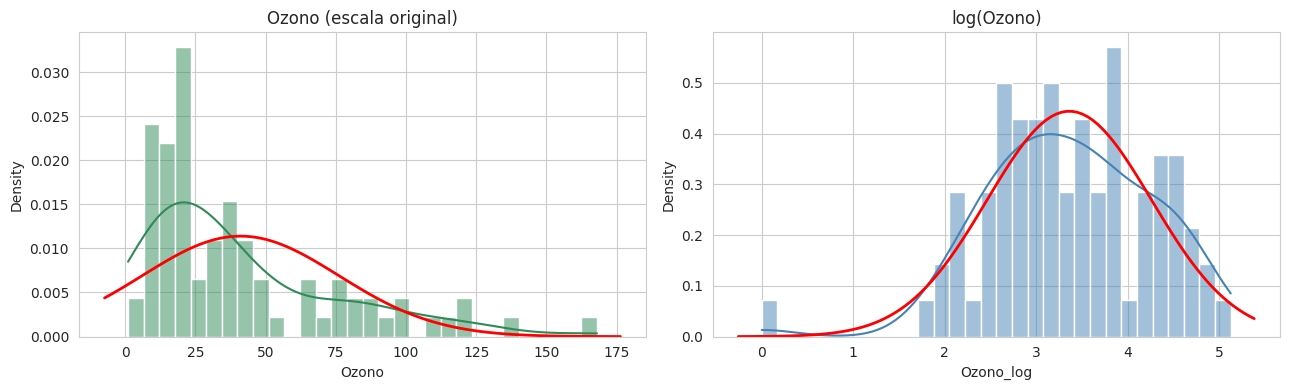

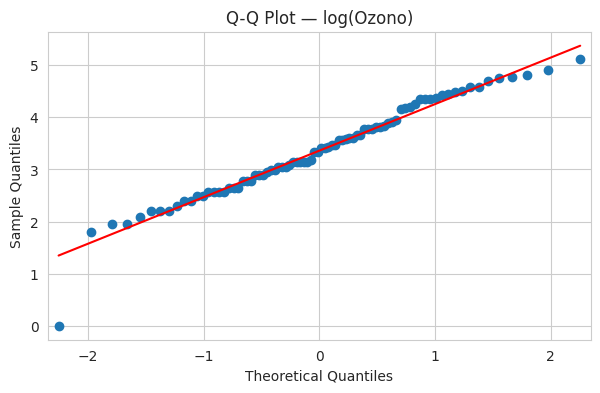

In [7]:
# Comparación visual: histograma + curva normal ANTES y DESPUÉS del log
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(airq_dt['Ozono'].dropna(), kde=True, stat="density",
             color="seagreen", bins=30, ax=axes[0])
x0 = np.linspace(*axes[0].get_xlim(), 100)
axes[0].plot(x0, norm.pdf(x0, mean_oz, std_oz), 'r', linewidth=2)
axes[0].set_title("Ozono (escala original)")

sns.histplot(airq_dt['Ozono_log'].dropna(), kde=True, stat="density",
             color="steelblue", bins=30, ax=axes[1])
x1 = np.linspace(*axes[1].get_xlim(), 100)
axes[1].plot(x1, norm.pdf(x1, airq_dt['Ozono_log'].mean(), airq_dt['Ozono_log'].std()),
             'r', linewidth=2)
axes[1].set_title("log(Ozono)")

plt.tight_layout()
plt.show()

# Q-Q plot de la variable transformada, para comparar con el de la sección 1.1
sm.qqplot(airq_dt['Ozono_log'].dropna(), line='s')
plt.title("Q-Q Plot — log(Ozono)")
plt.show()


### 1.4 Chequeo rápido de otras variables numéricas

Para completar el panorama, aplicamos Shapiro-Wilk a `Vient` (viento) y `RadSol` (radiación solar), sin repetir todo el detalle gráfico. Esto también sirve como ejemplo de cómo **automatizar** el chequeo de normalidad cuando hay varias variables.


In [8]:
variables_numericas = ['Vient', 'RadSol']

for var in variables_numericas:
    datos = airq_dt[var].dropna()
    stat, p = shapiro(datos)
    veredicto = "compatible con normal" if p > alpha else "NO compatible con normal"
    print(f"{var:8s} -> Shapiro p-value = {p:.4f}  ({veredicto})")

hallazgo("Ozono resultó NO normal (con o sin log, según el criterio que se use) y "
          "RadSol tampoco. Esto es importante para la Sección 2: usaremos un método "
          "de detección de outliers que NO dependa del supuesto de normalidad (IQR), "
          "en vez de reglas basadas en desviaciones estándar (que sí asumen normalidad).")


Vient    -> Shapiro p-value = 0.2420  (compatible con normal)
RadSol   -> Shapiro p-value = 0.0001  (NO compatible con normal)
🔎 HALLAZGO: Ozono resultó NO normal (con o sin log, según el criterio que se use) y RadSol tampoco. Esto es importante para la Sección 2: usaremos un método de detección de outliers que NO dependa del supuesto de normalidad (IQR), en vez de reglas basadas en desviaciones estándar (que sí asumen normalidad).


---
## 2. Detección de valores atípicos (outliers)

### ¿Por qué se hace este análisis?

Los valores atípicos pueden **distorsionar drásticamente** estimaciones como la media, la varianza, y los coeficientes de un modelo. Antes de imputar datos faltantes (Sección 3) o de usar la variable en cualquier análisis, hay que saber si existen valores extremos y decidir qué hacer con ellos.

### Consideraciones antes de decidir

- **Un outlier no es automáticamente un error.** Puede deberse a errores de medición o de entrada de datos, pero también puede ser una **observación válida** (por ejemplo, un día de alta contaminación real). Eliminar outliers sin investigar su causa es una mala práctica.
- **El método de detección debe ser coherente con lo que ya sabemos de la variable.** Como en la Sección 1 encontramos que Ozono **no es normal**, usamos el método del **rango intercuartílico (IQR)**, que no asume ninguna distribución específica — a diferencia de reglas como "más de 3 desviaciones estándar de la media", que sí asumen normalidad.
- **Conviene mirar también por subgrupos.** Un valor puede parecer atípico a nivel global pero ser normal dentro de un subgrupo (por ejemplo, un mes con más contaminación). Por eso comparamos el boxplot general con el boxplot por mes.


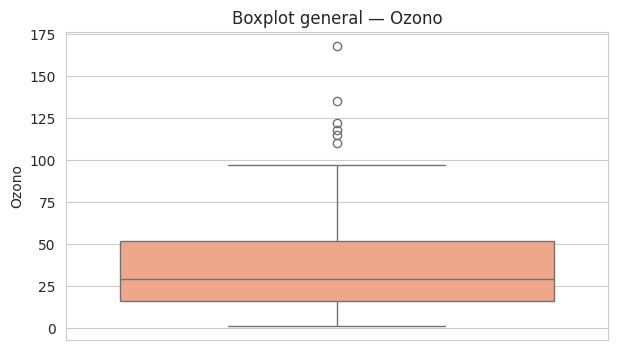

/tmp/ipykernel_601/3492952570.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Mes', y='Ozono', data=airq_dt, palette="Oranges")


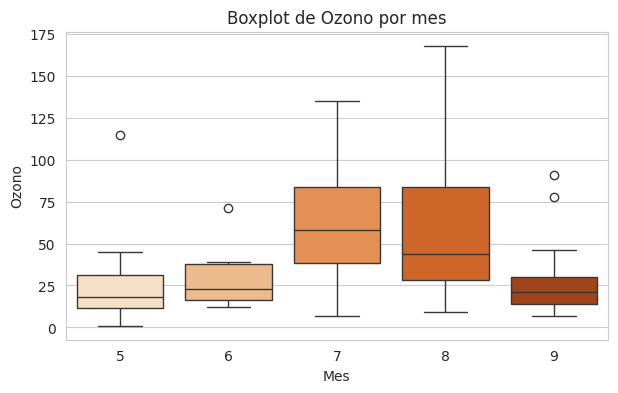

In [9]:
# Boxplot general: visualiza mediana, cuartiles, bigotes y outliers
# (los puntos fuera de los bigotes) de un solo vistazo.
sns.boxplot(y='Ozono', data=airq_dt, color="lightsalmon")
plt.title("Boxplot general — Ozono")
plt.show()

# Boxplot por mes: permite ver si los valores extremos se concentran
# en algún mes en particular, lo cual sería una pista de que no son
# errores aleatorios sino un patrón real (por ejemplo, estacional).
sns.boxplot(x='Mes', y='Ozono', data=airq_dt, palette="Oranges")
plt.title("Boxplot de Ozono por mes")
plt.show()


In [10]:
# Método del rango intercuartílico (IQR)
# No asume ninguna distribución particular de los datos: por eso es
# el método recomendado dado que Ozono no resultó normal (Sección 1).

Q1 = airq_dt['Ozono'].quantile(0.25)
Q3 = airq_dt['Ozono'].quantile(0.75)
IQR = Q3 - Q1

LI = Q1 - 1.5 * IQR   # límite inferior
LS = Q3 + 1.5 * IQR   # límite superior

print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"Límite inferior (LI) = {LI}")
print(f"Límite superior (LS) = {LS}")

outliers_sup = airq_dt[airq_dt['Ozono'] >= LS]
outliers_inf = airq_dt[airq_dt['Ozono'] <= LI]
n_outliers = len(outliers_sup) + len(outliers_inf)

print(f"\nValores atípicos superiores (n={len(outliers_sup)}):")
print(outliers_sup[['Ozono', 'Mes', 'Dia']])
print(f"\nValores atípicos inferiores (n={len(outliers_inf)}):")
print(outliers_inf[['Ozono', 'Mes', 'Dia']] if len(outliers_inf) else "Ninguno")

pct_outliers = 100 * n_outliers / airq_dt['Ozono'].notna().sum()
hallazgo(f"Se detectaron {n_outliers} valores atípicos en Ozono "
          f"({pct_outliers:.1f}% de las observaciones no nulas), todos por el "
          f"extremo superior. Esto es consistente con la asimetría positiva "
          f"encontrada en la Sección 1 (cola larga hacia la derecha): la variable "
          f"tiene episodios puntuales de concentración de ozono muy alta.")


Q1 = 16.0, Q3 = 51.5, IQR = 35.5
Límite inferior (LI) = -37.25
Límite superior (LS) = 104.75

Valores atípicos superiores (n=6):
    Ozono  Mes  Dia
15  118.0    8   29
20  110.0    8    9
51  135.0    7    1
56  115.0    5   30
66  122.0    8    7
91  168.0    8   25

Valores atípicos inferiores (n=0):
Ninguno
🔎 HALLAZGO: Se detectaron 6 valores atípicos en Ozono (7.3% de las observaciones no nulas), todos por el extremo superior. Esto es consistente con la asimetría positiva encontrada en la Sección 1 (cola larga hacia la derecha): la variable tiene episodios puntuales de concentración de ozono muy alta.


### Decisión: ¿qué hacer con estos outliers?

Recordando las alternativas vistas en clase (Hernández et al., 2004): ignorar, filtrar la columna, filtrar la fila, reemplazar el valor, o discretizar.

En este caso **no se recomienda eliminarlos directamente**, porque:

1. Se concentran en meses específicos (revísalo en el boxplot por mes), lo que sugiere un patrón real y no un error aleatorio de captura.
2. Solo representan un porcentaje bajo de las observaciones, por lo que no van a dominar el análisis si se usan estadísticos robustos (como la mediana) en los pasos siguientes.

**Por eso, en la Sección 3 usaremos la mediana (no la media) para imputar los datos faltantes de Ozono** — precisamente porque ya sabemos que esta variable tiene outliers y no es normal, y la media es muy sensible a ambas cosas.


---
## 3. Detección y corrección de datos faltantes

### ¿Por qué se hace este análisis?

Los datos faltantes, si no se tratan, pueden: reducir el tamaño de muestra disponible, introducir sesgo (si la ausencia no es aleatoria), o directamente impedir aplicar ciertos algoritmos (muchos requieren datasets completos, como PCA).

### Consideraciones antes de decidir

- **Primero hay que identificar el tipo de ausencia** (visto en clase): MCAR (completamente al azar), MAR (al azar, pero relacionada con otra variable observada) o MNAR (no al azar). El tipo de ausencia condiciona qué tan riesgosa es una imputación simple.
- **El método de imputación debe ser coherente con lo que ya sabemos de la variable.** Como Ozono **no es normal** y **tiene outliers** (Secciones 1 y 2), imputar con la **media** es una mala idea: la media está sesgada por los valores extremos. La **mediana** es más robusta en este escenario.
- **Imputar no es gratis.** Cualquier método de imputación simple (media, mediana) reduce artificialmente la varianza real de la variable y puede distorsionar su distribución. Siempre hay que evaluar si el porcentaje de datos faltantes es razonable para imputar, o si es preferible otra estrategia (filtrar filas/columnas, segmentar, etc.).


In [11]:
# Conteo de datos faltantes por columna: primer diagnóstico cuantitativo.
faltantes = airq_dt.isnull().sum()
print(faltantes)

pct_faltantes = (faltantes / len(airq_dt) * 100).round(1)
print("\nPorcentaje de datos faltantes por columna:")
print(pct_faltantes[pct_faltantes > 0])


Ozono        18
RadSol        4
Vient         0
Temp          0
Mes           0
Dia           0
Ozono_log    18
dtype: int64

Porcentaje de datos faltantes por columna:
Ozono        18.0
RadSol        4.0
Ozono_log    18.0
dtype: float64


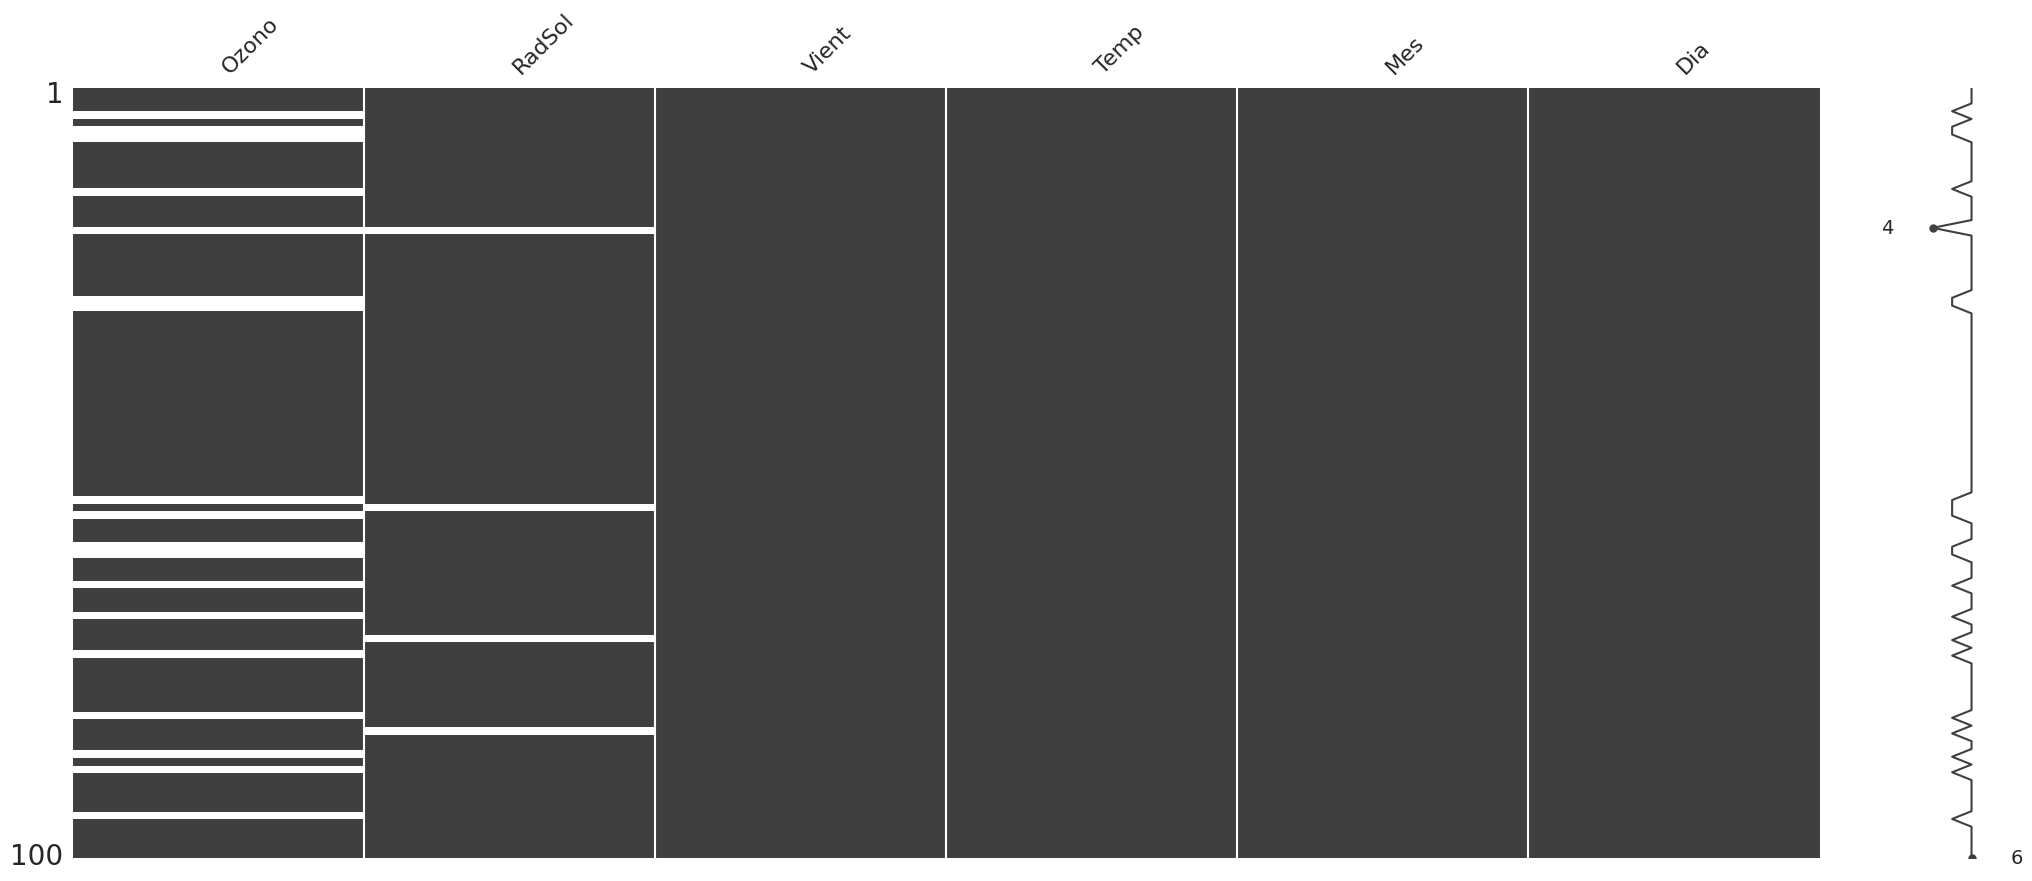

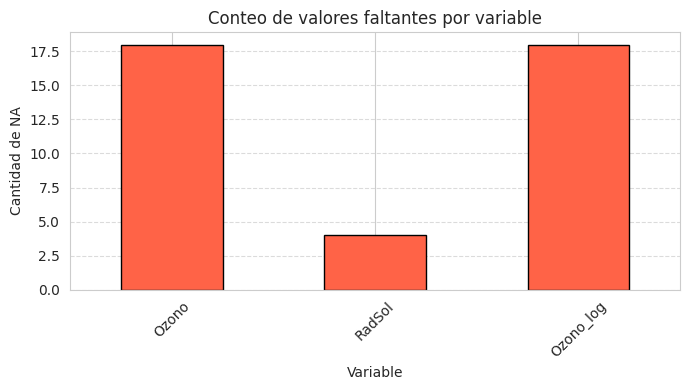

In [12]:
# Visualización de patrones de datos faltantes con missingno.
# msno.matrix muestra, fila por fila, dónde hay datos (barra) y dónde
# faltan (espacio blanco); permite detectar visualmente si los huecos
# de distintas columnas coinciden (lo que sugeriría una causa común).
msno.matrix(airq_dt[['Ozono', 'RadSol', 'Vient', 'Temp', 'Mes', 'Dia']])
plt.show()

# Gráfico de barras simple con el conteo de NA por variable
missing_counts = airq_dt.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

missing_counts.plot(kind='bar', color='tomato', edgecolor='black')
plt.title("Conteo de valores faltantes por variable")
plt.ylabel("Cantidad de NA")
plt.xlabel("Variable")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 3.1 ¿MCAR, MAR o MNAR? Un chequeo práctico

**Por qué:** si los datos faltantes de Ozono se concentraran en un mes específico, eso sería evidencia de que la ausencia **no es completamente al azar** (MCAR), sino que está relacionada con una variable observada — es decir, **MAR**. Esto no cambia necesariamente el método de imputación que usaremos aquí (mediana simple), pero sí es información importante: en un análisis más riguroso, convendría imputar por grupo (por ejemplo, mediana por mes) en vez de usar una única mediana global.


In [13]:
# Proporción de datos faltantes de Ozono, desglosada por mes
resumen_mes = airq_dt.groupby('Mes').agg(
    total=('Ozono', 'size'),
    faltantes=('Ozono', lambda s: s.isna().sum())
)
resumen_mes['pct_faltante'] = (resumen_mes['faltantes'] / resumen_mes['total'] * 100).round(1)
print(resumen_mes)

# Interpretación automática: si algún mes concentra una proporción
# mucho más alta que el resto, es una señal de MAR en vez de MCAR.
pct_max = resumen_mes['pct_faltante'].max()
pct_promedio_resto = resumen_mes.loc[resumen_mes['pct_faltante'] != pct_max, 'pct_faltante'].mean()
mes_critico = resumen_mes['pct_faltante'].idxmax()

if pct_max > 2 * pct_promedio_resto:
    tipo_ausencia = (f"probablemente MAR (al azar, pero relacionada con 'Mes'): "
                      f"el mes {mes_critico} concentra {pct_max}% de datos faltantes, "
                      f"muy por encima del promedio del resto de meses ({pct_promedio_resto:.1f}%).")
else:
    tipo_ausencia = "compatible con MCAR: la proporción de faltantes es similar entre meses."

hallazgo(f"El patrón de ausencia de Ozono es {tipo_ausencia}")


     total  faltantes  pct_faltante
Mes                                
5       22          3          13.6
6       16          9          56.2
7       17          3          17.6
8       24          3          12.5
9       21          0           0.0
🔎 HALLAZGO: El patrón de ausencia de Ozono es probablemente MAR (al azar, pero relacionada con 'Mes'): el mes 6 concentra 56.2% de datos faltantes, muy por encima del promedio del resto de meses (10.9%).


### 3.2 Imputación de datos faltantes

**Decisión tomada:** dado que Ozono no es normal y tiene outliers (Secciones 1 y 2), imputamos con la **mediana** en vez de la media. La mediana no se ve afectada por los valores extremos, por lo que representa mejor un "valor típico" en este caso.

Para comparar, mostramos también qué habría pasado con la media (y por qué difiere).


In [14]:
media_oz = airq_dt['Ozono'].mean()
mediana_oz = airq_dt['Ozono'].median()

print(f"Media de Ozono (sin imputar):   {media_oz:.2f}")
print(f"Mediana de Ozono (sin imputar): {mediana_oz:.2f}")
print(f"Diferencia: {abs(media_oz - mediana_oz):.2f} "
      f"(cuanto mayor la diferencia, más está 'jalando' la asimetría/outliers a la media)")

# Imputación por la MEDIANA (decisión justificada arriba)
airq_dt['Oz_imp_mediana'] = airq_dt['Ozono'].fillna(mediana_oz)

# Imputación por la MEDIA, solo para comparar el efecto
airq_dt['Oz_imp_media'] = airq_dt['Ozono'].fillna(media_oz)

hallazgo(f"La media ({media_oz:.2f}) es distinta de la mediana ({mediana_oz:.2f}) por "
          f"{abs(media_oz - mediana_oz):.2f} unidades, reflejo directo de los outliers "
          f"y la asimetría detectados antes. Se usará la MEDIANA para imputar Ozono.")


Media de Ozono (sin imputar):   41.07
Mediana de Ozono (sin imputar): 29.00
Diferencia: 12.07 (cuanto mayor la diferencia, más está 'jalando' la asimetría/outliers a la media)
🔎 HALLAZGO: La media (41.07) es distinta de la mediana (29.00) por 12.07 unidades, reflejo directo de los outliers y la asimetría detectados antes. Se usará la MEDIANA para imputar Ozono.


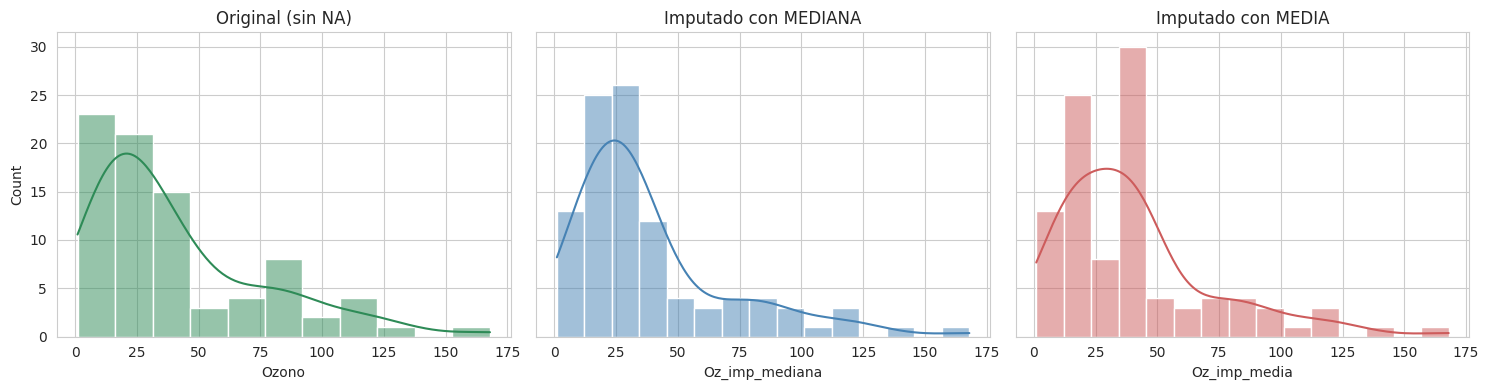

In [15]:
# Comparación visual del efecto de cada método de imputación sobre
# la distribución de la variable. Lo esperable es que la imputación por
# media "aplaste" la forma real de la distribución más que la mediana,
# especialmente si hay muchos valores faltantes.

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

sns.histplot(airq_dt['Ozono'].dropna(), kde=True, ax=axes[0], color="seagreen")
axes[0].set_title("Original (sin NA)")

sns.histplot(airq_dt['Oz_imp_mediana'], kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Imputado con MEDIANA")

sns.histplot(airq_dt['Oz_imp_media'], kde=True, ax=axes[2], color="indianred")
axes[2].set_title("Imputado con MEDIA")

plt.tight_layout()
plt.show()


### 3.3 Imputación múltiple de columnas numéricas

**Por qué:** en la práctica rara vez se imputa una sola columna; es común necesitar limpiar varias variables numéricas a la vez antes de modelar. `SimpleImputer` de scikit-learn permite aplicar la misma estrategia (media, mediana, moda, valor constante) a varias columnas de forma consistente y reproducible (útil también dentro de un pipeline de modelado).

**Consideración:** aquí usamos `strategy='median'` para todas las columnas numéricas con datos faltantes (Ozono y RadSol), siguiendo el mismo criterio de robustez frente a outliers definido arriba. Si alguna columna fuera claramente normal y sin outliers, usar la media sería razonable — la elección de estrategia no debería ser automática, sino basada en el diagnóstico de cada variable.


In [16]:
# Seleccionamos las columnas numéricas originales relevantes
# (excluimos las columnas auxiliares que creamos nosotros: Ozono_log,
# Oz_imp_mediana, Oz_imp_media)
cols_originales = ['Ozono', 'RadSol', 'Vient', 'Temp', 'Mes', 'Dia']

imp = SimpleImputer(strategy='median')
airq_imp_df = pd.DataFrame(
    imp.fit_transform(airq_dt[cols_originales]),
    columns=cols_originales
)

print("Antes de imputar (conteo de NA):")
print(airq_dt[cols_originales].isnull().sum())
print("\nDespués de imputar (conteo de NA):")
print(airq_imp_df.isnull().sum())

print("\nVista previa del dataset imputado:")
print(airq_imp_df.head())


Antes de imputar (conteo de NA):
Ozono     18
RadSol     4
Vient      0
Temp       0
Mes        0
Dia        0
dtype: int64

Después de imputar (conteo de NA):
Ozono     0
RadSol    0
Vient     0
Temp      0
Mes       0
Dia       0
dtype: int64

Vista previa del dataset imputado:
   Ozono  RadSol  Vient  Temp  Mes   Dia
0   21.0   259.0   15.5  76.0  9.0  12.0
1   32.0    92.0   12.0  61.0  5.0  24.0
2   20.0    37.0    9.2  65.0  6.0  18.0
3   29.0   139.0    8.6  82.0  7.0  11.0
4   28.0   273.0   11.5  82.0  8.0  13.0


---
## Conclusiones y checklist del taller

Este taller mostró cómo los tres temas se conectan en una **secuencia lógica de decisiones**, no en pasos aislados:

1. **Normalidad:** Ozono resultó no-normal (asimetría positiva, tests formales rechazan H0). Se probó una transformación logarítmica, que mejora la simetría (útil si más adelante se necesitara una variable normal para otro método).
2. **Outliers:** dado que Ozono no es normal, se usó el método IQR (no paramétrico) en vez de reglas basadas en desviación estándar. Se encontraron outliers superiores, concentrados en ciertos meses — patrón real, no error aleatorio.
3. **Datos faltantes:** el patrón de ausencia de Ozono resultó relacionado con el mes (posible MAR). Dado que la variable no es normal y tiene outliers, se imputó con la **mediana** en vez de la media, y se aplicó la misma lógica al imputar varias columnas a la vez con `SimpleImputer`.

### Preguntas para repasar

1. ¿Por qué no basta con mirar un histograma para decidir si una variable es normal?
2. ¿Qué información nueva aporta la transformación logarítmica, y qué cuidado hay que tener antes de aplicarla?
3. ¿Por qué el método IQR es más apropiado que una regla basada en desviaciones estándar cuando la variable no es normal?
4. ¿Por qué imputar con la media puede ser una mala decisión si la variable tiene outliers?
5. ¿Qué diferencia hay entre datos MCAR y MAR, y por qué esa diferencia es relevante al momento de imputar?
